# TTM Granite (IBM Transformer) — Fine-Tuned Forecasting

## Project Overview

This notebook demonstrates **fine-tuned time-series forecasting** using IBM's **Tiny Time Mixers (TTM)** foundation model from the Granite family. We start from the same pre-trained TTM checkpoint used in the zero-shot notebook, then **fine-tune the prediction head** on our training data to adapt to Spain's electricity load patterns.

### The Task
Predict **96 hours (4 days) ahead** of Spain's electricity grid total load (in MW), using 4 years of historical energy and weather data (2015–2018).

### Why Fine-Tune?
- **Domain adaptation**: Adapts the pre-trained model to our specific energy load distribution
- **No feature engineering**: Still feeds raw time series — the transformer extracts patterns internally
- **Best of both worlds**: Leverages pre-trained temporal knowledge + learns domain-specific patterns

### Comparison with Other Notebooks
| Aspect | CatBoost (Direct/WF) | TTM Zero-Shot | TTM Fine-Tuned |
|--------|---------------------|---------------|----------------|
| Feature Engineering | 70+ hand-crafted features | None (raw series) | None (raw series) |
| Training | Required (96 or 1 model) | None (pre-trained) | Fine-tune prediction head |
| Context Window | Lag features at fixed offsets | 1536 continuous time steps | 1536 continuous time steps |
| Architecture | Gradient boosted trees | Transformer (Time Mixer) | Transformer (Time Mixer) |

---

## 1. Install Dependencies

TTM requires the `tsfm_public` package from IBM Research (Granite Time Series Foundation Models).

In [1]:
# Fix Keras 3 / TensorFlow compatibility for HuggingFace Trainer
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

# Install tsfm_public (IBM Granite Time Series Foundation Models)
!pip install "tsfm_public[notebooks]" --quiet

print("Installation complete.")

Installation complete.


## 2. Import Libraries

In [2]:
import math
import os
import tempfile

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import torch
import warnings

from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from transformers import EarlyStoppingCallback, Trainer, TrainingArguments, set_seed
from tqdm.notebook import tqdm

from tsfm_public import (
    TimeSeriesPreprocessor,
    TinyTimeMixerForPrediction,
    TrackingCallback,
    count_parameters,
    get_datasets,
)
from tsfm_public.toolkit.time_series_preprocessor import prepare_data_splits

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

SEED = 42
set_seed(SEED)

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'}")
print("Libraries loaded successfully.")

PyTorch version: 2.11.0
Device: mps
Libraries loaded successfully.


## 3. Load Data

We load two datasets:
- **`energy_data.csv`** — Hourly Spanish electricity data (generation by source, total load, price) from 2015–2018
- **`weather_data.csv`** — Hourly weather observations (temperature, humidity, wind, clouds, etc.)

Both datasets are indexed by their timestamp columns and joined on the datetime index.

In [3]:
# Load CSVs
df_energy = pd.read_csv('Data/energy_data.csv')
df_weather = pd.read_csv('Data/weather_data.csv')

print(f"Energy data shape: {df_energy.shape}")
print(f"Weather data shape: {df_weather.shape}")
print(f"\nEnergy columns: {df_energy.columns.tolist()}")
print(f"\nWeather columns: {df_weather.columns.tolist()}")

Energy data shape: (35064, 17)
Weather data shape: (35064, 12)

Energy columns: ['time', 'generation biomass', 'generation fossil brown coal/lignite', 'generation fossil gas', 'generation fossil hard coal', 'generation fossil oil', 'generation hydro pumped storage consumption', 'generation hydro run-of-river and poundage', 'generation hydro water reservoir', 'generation nuclear', 'generation other', 'generation other renewable', 'generation solar', 'generation waste', 'generation wind onshore', 'total load actual', 'price actual']

Weather columns: ['dt_iso', 'temp', 'temp_min', 'temp_max', 'pressure', 'humidity', 'wind_speed', 'wind_deg', 'rain_1h', 'rain_3h', 'snow_3h', 'clouds_all']


## 4. Data Preprocessing

### Steps:
1. **Parse timestamps** to UTC-aware datetime objects
2. **Set datetime index** for time-series alignment
3. **Inner join** energy and weather on the timestamp index
4. **Resample to hourly frequency** with forward-fill to handle gaps
5. **Select target + exogenous columns** — `total load actual` (MW) plus weather features for channel mixing

In [4]:
# Parse and index timestamps
df_weather['dt_iso'] = pd.to_datetime(df_weather['dt_iso'], utc=True, errors='coerce')
df_weather.set_index('dt_iso', inplace=True)

df_energy['time'] = pd.to_datetime(df_energy['time'], utc=True, errors='coerce')
df_energy.set_index('time', inplace=True)

# Join on datetime index
df = df_energy.join(df_weather, how='inner')
df.index = pd.to_datetime(df.index, utc=True)

# Resample to consistent hourly frequency and forward-fill gaps
full_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq='h')
df = df.reindex(full_index)
df = df.ffill()

# Keep target + exogenous weather features for channel mixing
EXOG_COLS = ['temp', 'humidity', 'wind_speed', 'pressure', 'clouds_all']
df = df[['total load actual'] + EXOG_COLS]

# Drop any remaining NaN rows
df = df.dropna()

print(f"Combined dataset shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Columns: {df.columns.tolist()}")
print(f"Missing values: {df.isnull().sum().sum()}")

Combined dataset shape: (35064, 6)
Date range: 2014-12-31 23:00:00+00:00 to 2018-12-31 22:00:00+00:00
Columns: ['total load actual', 'temp', 'humidity', 'wind_speed', 'pressure', 'clouds_all']
Missing values: 0


## 5. Exploratory Visualization

Let's visualize the full time series of total electricity load to understand its patterns — daily cycles, seasonal trends, and any anomalies.

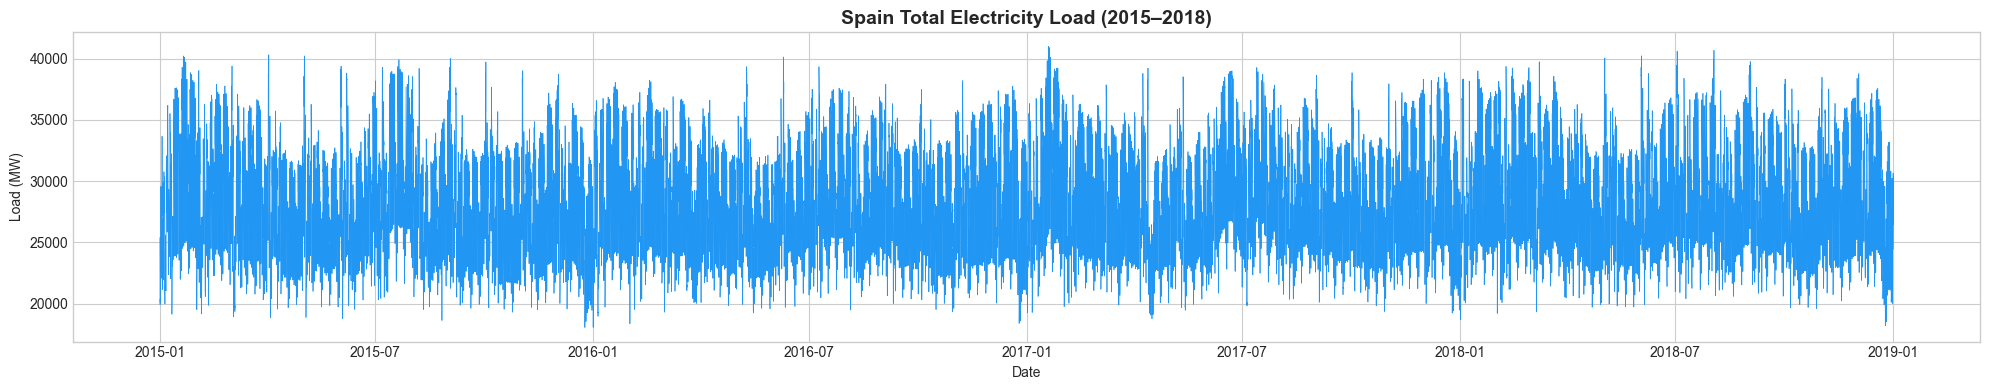


Basic Statistics:


,total load actual,temp,humidity,wind_speed,pressure,clouds_all
count,35064.0,35064.0,35064.0,35064.0,35064.0,35064.0
mean,28697.6,289.7,69.7,2.4,1017.0,20.8
std,4575.9,6.5,10.3,1.0,7.9,17.8
min,18041.0,270.0,28.0,0.7,973.9,0.0
25%,24806.8,284.3,62.9,1.7,1013.8,6.7
50%,28902.0,289.1,69.9,2.1,1017.3,16.5
75%,32194.2,295.4,77.0,2.7,1021.0,30.9
max,41015.0,304.1,98.2,8.3,1040.5,92.0


In [5]:
fig, ax = plt.subplots(figsize=(20, 4))
ax.plot(df.index, df['total load actual'], linewidth=0.5, color='#2196F3')
ax.set_title('Spain Total Electricity Load (2015\u20132018)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Load (MW)')
ax.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

print(f"\nBasic Statistics:")
display(df.describe().round(1))

## 6. Train / Test Split

**Same split as all other notebooks** for direct comparison:
- **Training period**: 2015-01-01 to 2017-10-28 (~2.8 years) — **used for fine-tuning**
- **Test set**: 2018-01-01 onwards (~1 year)

> **Note**: Unlike zero-shot, we now **use the training data to fine-tune** the TTM model's prediction head.

In [6]:
# Chronological split — identical to CatBoost notebooks
df_train = df.loc['2015-01-01':'2017-10-28 00:00:00'].copy()
df_test = df.loc['2018-01-01':].copy()

# Define column roles for TTM pipeline
feature_name = 'total load actual'
target_columns = [feature_name]
exog = EXOG_COLS  # weather features as control channels
timestamp_column = 'timestamp'
context_length = 1536   # 1536 hours (~64 days)
prediction_length = 96  # 96 hours (4 days)
fewshot_fraction = 1.0  # use 100% of training data

# TTM model config
TTM_MODEL_PATH = "ibm-granite/granite-timeseries-ttm-r2"
TTM_MODEL_REVISION = "1536-96-r2"
OUT_DIR = "ttm_finetuned_models/"

print(f"Training set: {df_train.shape[0]:,} rows ({df_train.index.min().date()} to {df_train.index.max().date()})")
print(f"Test set:     {df_test.shape[0]:,} rows ({df_test.index.min().date()} to {df_test.index.max().date()})")
print(f"Target: {target_columns}")
print(f"Exogenous: {exog}")
print(f"Context: {context_length}h, Prediction: {prediction_length}h")

Training set: 24,745 rows (2015-01-01 to 2017-10-28)
Test set:     8,759 rows (2018-01-01 to 2018-12-31)
Target: ['total load actual']
Exogenous: ['temp', 'humidity', 'wind_speed', 'pressure', 'clouds_all']
Context: 1536h, Prediction: 96h


## 7. Prepare Datasets (Official IBM Pipeline)

Using the **official TTM guidebook method** with:
- **`TimeSeriesPreprocessor`** with `scaling=True` (standard scaler)
- **`prepare_data_splits`** for fraction-based train/valid/test splitting
- **`get_datasets`** with `fewshot_fraction` for few-shot control
- **Channel mixing** with exogenous weather features (`temp`, `humidity`, `wind_speed`, `pressure`, `clouds_all`)

In [7]:
split_config = {"train": 0.85, "test": 0.075}

column_specifiers = {
    "timestamp_column": timestamp_column,
    "id_columns": [],
    "target_columns": target_columns,
    "control_columns": exog,
}

tsp = TimeSeriesPreprocessor(
    **column_specifiers,
    context_length=context_length,
    prediction_length=prediction_length,
    scaling=True,
    encode_categorical=False,
    scaler_type="standard",
)

# Prepare the input DataFrame (remove timezone, reset index for TSP)
input_df = df.copy()
input_df.index = input_df.index.tz_localize(None)
input_df = input_df.reset_index()
input_df.columns = [timestamp_column] + target_columns + exog

# Split data into DataFrames for reference
train_df, valid_df, test_df = prepare_data_splits(
    input_df, context_length=context_length, split_config=split_config
)

# Create PyTorch datasets
train_dataset, valid_dataset, test_dataset = get_datasets(
    tsp,
    input_df,
    split_config=split_config,
    fewshot_fraction=fewshot_fraction,
    enable_padding=False,
    fewshot_location="first",
)

print(f"Data lengths: train = {len(train_dataset)}, valid = {len(valid_dataset)}, test = {len(test_dataset)}")
print(f"TSP num_input_channels: {tsp.num_input_channels}")
print(f"TSP prediction_channel_indices: {tsp.prediction_channel_indices}")
print(f"TSP exogenous_channel_indices: {tsp.exogenous_channel_indices}")

# Inspect one sample
sample = train_dataset[0]
print(f"\nSample keys: {list(sample.keys())}")
print(f"past_values shape: {sample['past_values'].shape}")
print(f"future_values shape: {sample['future_values'].shape}")

Data lengths: train = 28173, valid = 2536, test = 2534
TSP num_input_channels: 6
TSP prediction_channel_indices: [0]
TSP exogenous_channel_indices: [1, 2, 3, 4, 5]

Sample keys: ['past_values', 'future_values', 'past_observed_mask', 'future_observed_mask', 'timestamp', 'id']
past_values shape: torch.Size([1536, 6])
future_values shape: torch.Size([96, 6])


## 8. Load Pre-Trained TTM Model for Fine-Tuning

Load the TTM R2 model with **forecast channel mixing** enabled, using TSP-derived channel configuration.
The model uses `num_input_channels` and `exogenous_channel_indices` from the preprocessor to handle multivariate input with weather features.

In [8]:
# Instantiate the model with channel mixing (official guidebook method)
set_seed(SEED)
finetune_forecast_model = TinyTimeMixerForPrediction.from_pretrained(
    TTM_MODEL_PATH,
    num_input_channels=tsp.num_input_channels,
    prediction_channel_indices=tsp.prediction_channel_indices,
    exogenous_channel_indices=tsp.exogenous_channel_indices,
    fcm_use_mixer=True,
    fcm_context_length=12,
    enable_forecast_channel_mixing=True,
    decoder_mode="mix_channel",
    revision=TTM_MODEL_REVISION,
    fcm_prepend_past=True,
)

print(f"Model loaded: {TTM_MODEL_PATH} (revision: {TTM_MODEL_REVISION})")
print(f"Input channels: {tsp.num_input_channels} (target: {len(target_columns)}, exog: {len(exog)})")
print(f"Prediction channel indices: {tsp.prediction_channel_indices}")
print(f"Exogenous channel indices: {tsp.exogenous_channel_indices}")
print(f"Forecast channel mixing: enabled (fcm_context_length=12)")

Some weights of TinyTimeMixerForPrediction were not initialized from the model checkpoint at ibm-granite/granite-timeseries-ttm-r2 and are newly initialized: ['decoder.decoder_block.mixers.0.channel_feature_mixer.gating_block.attn_layer.bias', 'decoder.decoder_block.mixers.0.channel_feature_mixer.gating_block.attn_layer.weight', 'decoder.decoder_block.mixers.0.channel_feature_mixer.mlp.fc1.bias', 'decoder.decoder_block.mixers.0.channel_feature_mixer.mlp.fc1.weight', 'decoder.decoder_block.mixers.0.channel_feature_mixer.mlp.fc2.bias', 'decoder.decoder_block.mixers.0.channel_feature_mixer.mlp.fc2.weight', 'decoder.decoder_block.mixers.0.channel_feature_mixer.norm.norm.bias', 'decoder.decoder_block.mixers.0.channel_feature_mixer.norm.norm.weight', 'decoder.decoder_block.mixers.1.channel_feature_mixer.gating_block.attn_layer.bias', 'decoder.decoder_block.mixers.1.channel_feature_mixer.gating_block.attn_layer.weight', 'decoder.decoder_block.mixers.1.channel_feature_mixer.mlp.fc1.bias', 'dec

Model loaded: ibm-granite/granite-timeseries-ttm-r2 (revision: 1536-96-r2)
Input channels: 6 (target: 1, exog: 5)
Prediction channel indices: [0]
Exogenous channel indices: [1, 2, 3, 4, 5]
Forecast channel mixing: enabled (fcm_context_length=12)


## 9. Fine-Tune with HuggingFace Trainer

Following the **official IBM TTM guidebook**:
1. **Freeze backbone** — only tune the decoder/output layers
2. **AdamW + OneCycleLR** optimizer/scheduler
3. **EarlyStoppingCallback** with patience=40
4. **TrackingCallback** for monitoring
5. `learning_rate=0.00002`, `num_epochs=1000`, `batch_size=64`

In [9]:
print(
    "Number of params before freezing backbone",
    count_parameters(finetune_forecast_model),
)

# Freeze the backbone of the model
for param in finetune_forecast_model.backbone.parameters():
    param.requires_grad = False

# Count params
print(
    "Number of params after freezing the backbone",
    count_parameters(finetune_forecast_model),
)

Number of params before freezing backbone 3213765
Number of params after freezing the backbone 1187205


In [10]:
# Important parameters (from official guidebook)
learning_rate: float = 0.00002
num_epochs: int = 1000
patience: int = 40
batch_size: int = 256

print(f"Using learning rate = {learning_rate}")
finetune_forecast_args = TrainingArguments(
    output_dir=os.path.join(OUT_DIR, "output"),
    overwrite_output_dir=True,
    learning_rate=learning_rate,
    num_train_epochs=num_epochs,
    do_eval=True,
    eval_strategy="epoch",
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    dataloader_num_workers=0,
    report_to=None,
    save_strategy="epoch",
    logging_strategy="epoch",
    save_total_limit=1,
    logging_dir=os.path.join(OUT_DIR, "logs"),
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
)

early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=patience,
    early_stopping_threshold=0.0001,
)
tracking_callback = TrackingCallback()

optimizer = AdamW(finetune_forecast_model.parameters(), lr=learning_rate)
scheduler = OneCycleLR(
    optimizer,
    learning_rate,
    epochs=num_epochs,
    steps_per_epoch=math.ceil(len(train_dataset) / (batch_size)),
)

finetune_forecast_trainer = Trainer(
    model=finetune_forecast_model,
    args=finetune_forecast_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    callbacks=[early_stopping_callback, tracking_callback],
    optimizers=(optimizer, scheduler),
)

print(f"Trainer ready. Train: {len(train_dataset)}, Valid: {len(valid_dataset)}, Test: {len(test_dataset)}")

Using learning rate = 2e-05
Trainer ready. Train: 28173, Valid: 2536, Test: 2534


In [11]:
# Fine tune
finetune_forecast_trainer.train()

  0%|          | 0/111000 [00:00<?, ?it/s]

{'loss': 0.6553, 'grad_norm': 6.766894817352295, 'learning_rate': 8.005264057062757e-07, 'epoch': 1.0}


  0%|          | 0/10 [00:00<?, ?it/s]

{'eval_loss': 0.5564354658126831, 'eval_runtime': 5.6193, 'eval_samples_per_second': 451.302, 'eval_steps_per_second': 1.78, 'epoch': 1.0}
{'loss': 0.6117, 'grad_norm': 5.996312141418457, 'learning_rate': 8.021055650953277e-07, 'epoch': 2.0}


  0%|          | 0/10 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

{'eval_loss': 0.2635977864265442, 'eval_runtime': 7.1075, 'eval_samples_per_second': 356.804, 'eval_steps_per_second': 1.407, 'epoch': 224.0}
{'loss': 0.1742, 'grad_norm': 1.1008445024490356, 'learning_rate': 1.718870540849002e-05, 'epoch': 225.0}


  0%|          | 0/10 [00:00<?, ?it/s]

{'eval_loss': 0.26437610387802124, 'eval_runtime': 6.1473, 'eval_samples_per_second': 412.541, 'eval_steps_per_second': 1.627, 'epoch': 225.0}
{'train_runtime': 31861.3922, 'train_samples_per_second': 884.236, 'train_steps_per_second': 3.484, 'train_loss': 0.32625742609675107, 'epoch': 225.0}
[TrackingCallback] Mean Epoch Time = 136.04179623497856 seconds, Total Train Time = 31861.395875930786


TrainOutput(global_step=24975, training_loss=0.32625742609675107, metrics={'train_runtime': 31861.3922, 'train_samples_per_second': 884.236, 'train_steps_per_second': 3.484, 'total_flos': 1.126479898973952e+18, 'train_loss': 0.32625742609675107, 'epoch': 225.0})

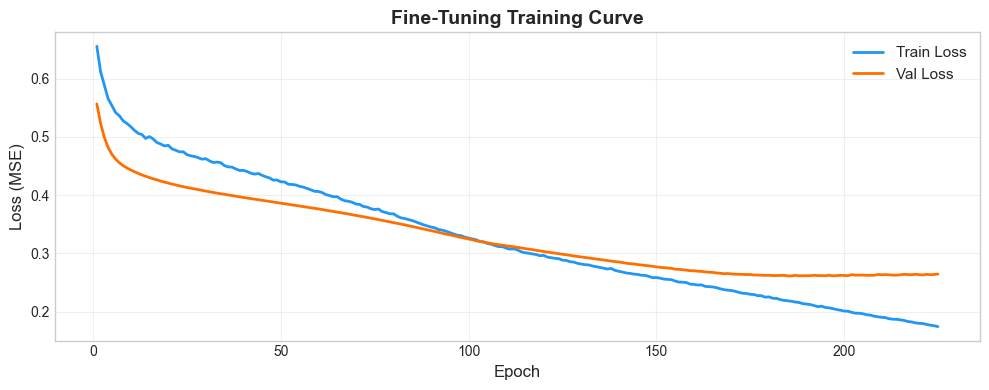

Best eval loss: 0.261109
Total epochs trained: 225


In [12]:
# Plot training curves from Trainer log history
log_history = finetune_forecast_trainer.state.log_history

train_losses = [x['loss'] for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_losses = [x['eval_loss'] for x in log_history if 'eval_loss' in x]
eval_epochs = [x['epoch'] for x in log_history if 'eval_loss' in x]
train_epochs = [x['epoch'] for x in log_history if 'loss' in x and 'eval_loss' not in x]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_epochs, train_losses, label='Train Loss', color='#2196F3', linewidth=2)
ax.plot(eval_epochs, eval_losses, label='Val Loss', color='#FF6F00', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss (MSE)', fontsize=12)
ax.set_title('Fine-Tuning Training Curve', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best eval loss: {min(eval_losses):.6f}")
print(f"Total epochs trained: {int(eval_epochs[-1])}")

## 10. Generate Forecasts on the Test Set

We first evaluate using the Trainer, then generate per-horizon forecasts:
1. Feed **TSP-scaled** multivariate context (target + exogenous weather channels)
2. The model predicts scaled target values
3. We **inverse-scale** predictions back to original MW using the TSP's fitted scaler

In [13]:
# Evaluate on test set using Trainer (official approach)
print("Test set evaluation:")
eval_results = finetune_forecast_trainer.evaluate(test_dataset)
print(eval_results)

# --- Generate per-horizon forecasts for detailed analysis ---
model = finetune_forecast_trainer.model
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
model = model.to(device)
model.eval()

CONTEXT_LENGTH = context_length
FORECAST_HORIZON = prediction_length

# Get the fitted scaler from TSP for inverse-transforming predictions
scaler_key = list(tsp.target_scaler_dict.keys())[0]
target_scaler = tsp.target_scaler_dict[scaler_key]
exog_scaler = tsp.scaler_dict.get(scaler_key, None)

# Prepare the full scaled dataset for inference
df_full = pd.concat([df_train, df_test])
all_channels = target_columns + exog
df_scaled = df_full[all_channels].copy()

# Apply TSP's fitted scaling
df_scaled[target_columns] = target_scaler.transform(df_scaled[target_columns])
if exog_scaler is not None and len(exog) > 0:
    df_scaled[exog] = exog_scaler.transform(df_scaled[exog])

values_scaled = df_scaled.values.astype(np.float32)  # (n_total, n_channels)
values_raw = df_full[feature_name].values.astype(np.float32)  # for actual comparison

# Index mapping
test_start_pos = len(df_train)
n_test = len(df_test)

forecast_rows = []
with torch.no_grad():
    for i in tqdm(range(n_test - FORECAST_HORIZON), desc="Generating forecasts"):
        pos = test_start_pos + i

        ctx_start = pos - CONTEXT_LENGTH + 1
        if ctx_start < 0:
            continue

        # Check we have enough future data for exogenous channels
        future_end = pos + 1 + FORECAST_HORIZON
        if future_end > len(values_scaled):
            continue

        # Scaled context (all channels: target + exogenous)
        context = values_scaled[ctx_start:pos + 1]  # (CONTEXT_LENGTH, n_channels)
        input_tensor = torch.tensor(context, dtype=torch.float32).unsqueeze(0).to(device)

        # Future values required for forecast channel mixing with exogenous features
        future_vals = values_scaled[pos + 1:future_end]  # (FORECAST_HORIZON, n_channels)
        future_tensor = torch.tensor(future_vals, dtype=torch.float32).unsqueeze(0).to(device)

        # Forward pass with past_values and future_values
        output = model(past_values=input_tensor, future_values=future_tensor)
        pred_scaled = output.prediction_outputs.squeeze().cpu().numpy()

        # Inverse-scale predictions back to original MW
        if pred_scaled.ndim == 1:
            pred_scaled = pred_scaled.reshape(-1, 1)
        pred_original = target_scaler.inverse_transform(pred_scaled)[:, 0]

        # Actual raw values
        actual = values_raw[pos + 1:pos + 1 + FORECAST_HORIZON]

        if len(actual) == FORECAST_HORIZON:
            timestamp = df_test.index[i]
            forecast_rows.append([timestamp, pred_original.tolist(), actual.tolist()])

forecast_df = pd.DataFrame(
    forecast_rows,
    columns=['time', feature_name + '_prediction', feature_name]
)
forecast_df.reset_index(drop=True, inplace=True)

print(f"\nGenerated {len(forecast_df):,} forecast windows, each with {FORECAST_HORIZON} steps")

Test set evaluation:


  0%|          | 0/10 [00:00<?, ?it/s]

{'eval_loss': 0.26016029715538025, 'eval_runtime': 6.7293, 'eval_samples_per_second': 376.56, 'eval_steps_per_second': 1.486, 'epoch': 225.0}


Generating forecasts:   0%|          | 0/8663 [00:00<?, ?it/s]


Generated 8,663 forecast windows, each with 96 steps


## 11. Evaluation Metrics

We evaluate using:
- **MAE** (Mean Absolute Error): Average absolute deviation in MW — directly interpretable
- **RMSE** (Root Mean Squared Error): Penalizes large errors more heavily
- **Per-horizon MAE**: Shows how accuracy degrades as we forecast further ahead

In [14]:
def compute_metrics(actual_col, prediction_col, label="CatBoost"):
    """
    Compute MSE, RMSE, MAE both as overall averages and per-horizon.
    
    Parameters:
        actual_col: Series of lists (actual values per forecast window)
        prediction_col: Series of lists (predicted values per forecast window)
        label: Name for the results column
    
    Returns:
        avg_metrics: DataFrame with overall MSE, RMSE, MAE
        horizon_metrics: DataFrame with per-horizon MSE, RMSE, MAE
    """
    a = np.asarray(actual_col.tolist())
    p = np.asarray(prediction_col.tolist())

    mask = ~np.any(np.isnan(a), axis=1) & ~np.any(np.isnan(p), axis=1)

    mse = np.mean(np.square(a[mask, :] - p[mask, :]))
    mae = np.mean(np.abs(a[mask, :] - p[mask, :]))

    mse_t = np.mean(np.square(a[mask, :] - p[mask, :]), axis=0)
    mae_t = np.mean(np.abs(a[mask, :] - p[mask, :]), axis=0)

    avg_metrics = pd.DataFrame({
        label: {
            "Mean Squared Error (MSE)": f"{mse:,.1f}",
            "Root Mean Squared Error (RMSE)": f"{np.sqrt(mse):,.1f}",
            "Mean Absolute Error (MAE)": f"{mae:,.1f}",
        }
    })

    horizon_metrics = pd.DataFrame({
        "horizon_hour": np.arange(1, len(mse_t) + 1),
        "mse": mse_t,
        "rmse": np.sqrt(mse_t),
        "mae": mae_t,
    })

    return avg_metrics, horizon_metrics

In [15]:
avg_metrics, horizon_metrics = compute_metrics(
    forecast_df[feature_name],
    forecast_df[feature_name + '_prediction'],
    label="TTM Granite (Fine-Tuned)"
)

print("=" * 50)
print("OVERALL METRICS (averaged across all horizons)")
print("=" * 50)
display(avg_metrics)

OVERALL METRICS (averaged across all horizons)


,TTM Granite (Fine-Tuned)
Mean Squared Error (MSE),"6,055,497.1"
Root Mean Squared Error (RMSE),"2,460.8"
Mean Absolute Error (MAE),"1,761.5"


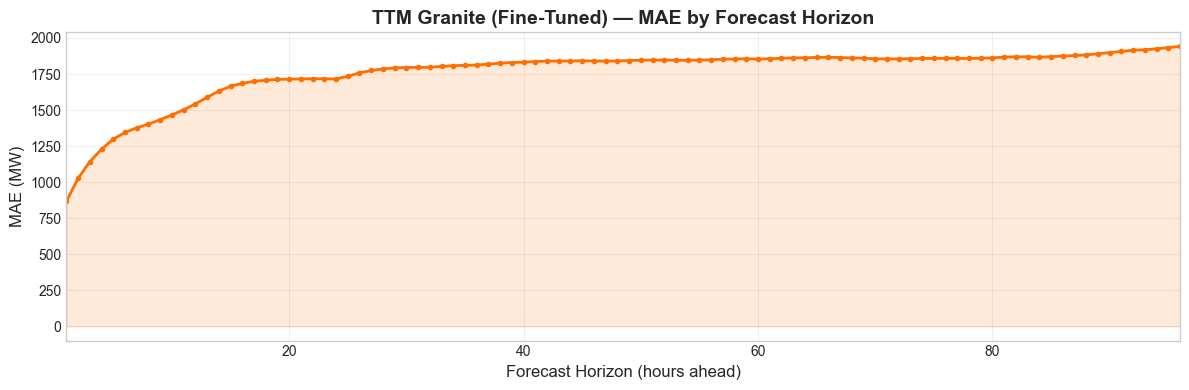

MAE at t+1:  868.9 MW
MAE at t+24: 1,715.6 MW
MAE at t+48: 1,841.0 MW
MAE at t+96: 1,942.1 MW


In [16]:
# Plot MAE by forecast horizon — shows how error grows with prediction distance
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(horizon_metrics['horizon_hour'], horizon_metrics['mae'], 
        color='#FF6F00', linewidth=2, marker='o', markersize=3)
ax.fill_between(horizon_metrics['horizon_hour'], 0, horizon_metrics['mae'], 
                alpha=0.15, color='#FF6F00')
ax.set_xlabel('Forecast Horizon (hours ahead)', fontsize=12)
ax.set_ylabel('MAE (MW)', fontsize=12)
ax.set_title('TTM Granite (Fine-Tuned) \u2014 MAE by Forecast Horizon', fontsize=14, fontweight='bold')
ax.set_xlim(1, FORECAST_HORIZON)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"MAE at t+1:  {horizon_metrics['mae'].iloc[0]:,.1f} MW")
print(f"MAE at t+24: {horizon_metrics['mae'].iloc[23]:,.1f} MW")
print(f"MAE at t+48: {horizon_metrics['mae'].iloc[47]:,.1f} MW")
print(f"MAE at t+96: {horizon_metrics['mae'].iloc[95]:,.1f} MW")

## 12. Forecast Visualization

Let's visually inspect predictions against actuals for several random forecast windows. The red line marks the forecast origin — everything to the right of it is predicted.

In [17]:
def create_timestamps(last_timestamp, freq, periods=1):
    """Generate `periods` timestamps after `last_timestamp` at a given frequency."""
    return pd.date_range(
        start=last_timestamp, freq=freq, periods=periods + 1
    ).tolist()[1:]

In [18]:
def plot_predictions(
    df, predictions_df, freq, timestamp_column, channel, indices, plot_context=None
):
    """
    Plot forecast windows alongside actual values.
    
    Parameters:
        df: DataFrame with actual values and a timestamp column
        predictions_df: DataFrame with 'time', prediction lists, and actual lists
        freq: Frequency string (e.g., 'h' for hourly)
        timestamp_column: Name of the timestamp column in df
        channel: Target column name
        indices: List of row indices from predictions_df to plot
        plot_context: Number of historical points to show before forecast
    """
    pred_col = f"{channel}_prediction"
    predictions_subset = [predictions_df.iloc[i] for i in indices]

    gt_df = df.copy()
    if not pd.api.types.is_datetime64_any_dtype(gt_df[timestamp_column]):
        gt_df[timestamp_column] = pd.to_datetime(gt_df[timestamp_column])
    gt_df = gt_df.set_index(timestamp_column)

    prediction_length = len(predictions_subset[0][pred_col])
    if plot_context is None:
        plot_context = 2 * prediction_length

    fig, axs = plt.subplots(len(indices), 1, figsize=(14, 3 * len(indices)), squeeze=False)
    axs = axs.flatten()

    for i, idx in enumerate(indices):
        row = predictions_subset[i]
        origin = pd.to_datetime(row[timestamp_column])
        if gt_df.index.tz is not None and origin.tzinfo is None:
            origin = origin.tz_localize(gt_df.index.tz)
        elif gt_df.index.tz is None and origin.tzinfo is not None:
            origin = origin.tz_localize(None)

        if origin not in gt_df.index:
            axs[i].set_title(f"Window {idx} \u2014 origin not found")
            continue

        loc = gt_df.index.get_loc(origin)
        ctx_start = max(0, loc - plot_context + 1)

        ts_ctx = gt_df.index[ctx_start:loc + 1]
        y_ctx = gt_df.iloc[ctx_start:loc + 1][channel].values

        act_end = min(loc + 1 + prediction_length, len(gt_df))
        ts_act = gt_df.index[loc + 1:act_end]
        y_act = gt_df.iloc[loc + 1:act_end][channel].values

        ts_pred = create_timestamps(origin, freq=freq, periods=prediction_length)
        y_pred = row[pred_col]

        # Plot
        ts_full = ts_ctx.append(ts_act) if len(ts_act) > 0 else ts_ctx
        y_full = np.concatenate([y_ctx, y_act])

        axs[i].plot(ts_full, y_full, label="Actual", color='#2196F3', linewidth=1.5)
        axs[i].plot(ts_pred[:len(y_pred)], y_pred, label="Predicted", 
                    color='#FF6F00', linewidth=1.5, linestyle='--')
        axs[i].axvline(x=origin, color='red', linestyle='-', alpha=0.7, label='Forecast Origin')
        axs[i].set_title(f"Forecast Window {idx} \u2014 Origin: {origin}", fontsize=11)
        axs[i].legend(loc='upper right', fontsize=8)
        axs[i].set_ylabel('Load (MW)')

    plt.tight_layout()
    plt.show()

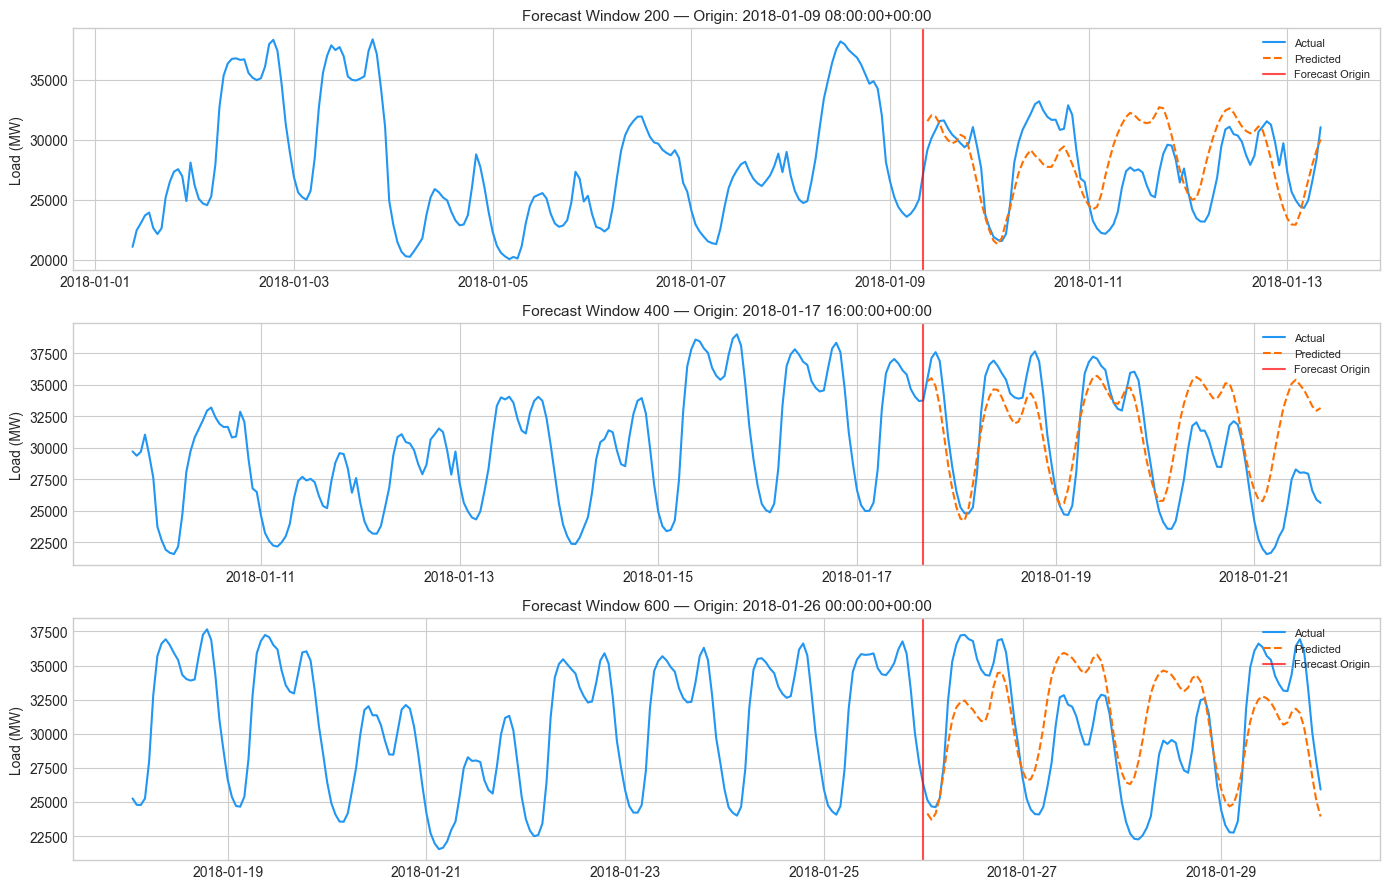

In [19]:
# Prepare test data for plotting
df_test_plot = df_test.copy().reset_index()
df_test_plot.rename(columns={'index': 'time'}, inplace=True)

# Plot 3 example forecast windows
plot_predictions(
    df=df_test_plot,
    predictions_df=forecast_df,
    freq="h",
    timestamp_column="time",
    channel=feature_name,
    indices=[200, 400, 600],
)

## 13. Save Results

Export the forecast DataFrame for downstream analysis or dashboard visualization.

In [20]:
import pickle

output_path = 'ttm_granite_finetuned_forecast.pkl'
with open(output_path, 'wb') as f:
    pickle.dump(forecast_df, f)

print(f"Forecast saved to {output_path}")
print(f"Shape: {forecast_df.shape}")

Forecast saved to ttm_granite_finetuned_forecast.pkl
Shape: (8663, 3)


## Summary

### What We Did (Official IBM TTM Guidebook Method)
1. **Loaded** 4 years of Spanish energy + weather data
2. **Preprocessed** into a clean hourly time series with **6 channels** (target + 5 exogenous weather features)
3. **Prepared datasets** using `TimeSeriesPreprocessor` (standard scaling) + `get_datasets` with `prepare_data_splits`
4. **Loaded** IBM's pre-trained TTM Granite R2 model with **forecast channel mixing** (`fcm_use_mixer=True`, `decoder_mode="mix_channel"`)
5. **Froze the backbone** and **fine-tuned** using HuggingFace `Trainer` with `EarlyStoppingCallback` (patience=40)
6. **Generated** 96-step-ahead forecasts with TSP inverse scaling

### Official Guidebook Configuration
| Parameter | Value |
|-----------|-------|
| `learning_rate` | 0.00002 |
| `num_epochs` | 1000 |
| `patience` | 40 |
| `batch_size` | 64 |
| `scaling` | True (standard) |
| `fewshot_fraction` | 1.0 (100% of training data) |
| `channel_mixing` | Enabled (fcm_context_length=12) |
| `exogenous_channels` | temp, humidity, wind_speed, pressure, clouds_all |

### Full Comparison
| Aspect | CatBoost (Direct) | CatBoost (Walk-Forward) | TTM Zero-Shot | TTM Fine-Tuned |
|--------|-------------------|------------------------|---------------|----------------|
| Feature Engineering | 70+ features | 70+ features | None | None (auto channel mixing) |
| Models Trained | 96 | 1 | 0 (pre-trained) | 1 (head only) |
| Training Time | Minutes | Minutes | 0 (inference only) | Minutes (Trainer) |
| Context | Fixed lag offsets | Rolling buffer | 1536 continuous hours | 1536 hours + 5 exog channels |
| Method | Manual features | Manual features | Raw univariate | Official IBM pipeline |

### Key Takeaway
The official IBM guidebook approach uses `TimeSeriesPreprocessor` + `get_datasets` + HuggingFace `Trainer` for a clean, reproducible pipeline. **Channel mixing** lets the model leverage exogenous weather signals alongside the target, while the `Trainer` handles training loop, checkpointing, and early stopping automatically.